In [5]:

#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


In [6]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()

In [7]:
#Cleanup data
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [ ]:
!pip install seaborn

In [9]:
import seaborn as sns

In [ ]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

In [ ]:
df_DA_US.dropna(subset = ['salary_year_avg'])

In [ ]:
df_US_exploded =df_DA_US.explode('job_skills')

In [ ]:
df_DA_US_group=df_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median'])


In [ ]:
df_DA_skills=df_DA_US_group.sort_values(by='count',ascending = False).head(10).sort_values(by='median',ascending = False).head(10)

In [ ]:
df_DA_top_pay=df_DA_US_group.sort_values(by='median',ascending = False).head(10)

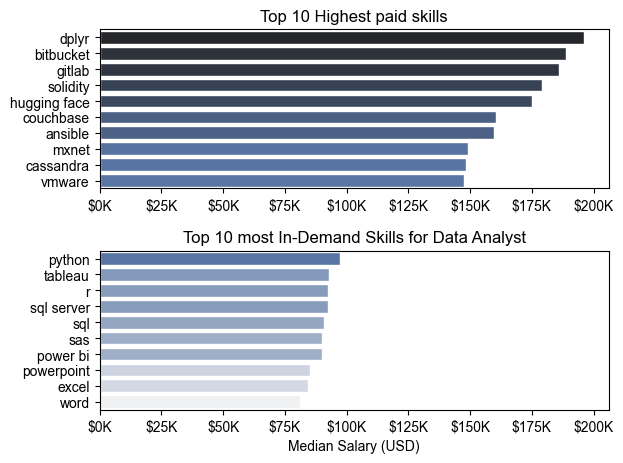

In [37]:
fig , ax = plt.subplots(2,1)

sns.set_theme(style = 'ticks')

#df_DA_top_pay.plot(kind = 'barh',y='median', ax= ax[0],legend =False)
#df_DA_top_pay[::-1].plot(kind = 'barh',y='median', ax= ax[0]) plot it in reverse
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r')
#ax[0].invert_yaxis()
ax[0].set_title("Top 10 Highest paid skills")
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].legend().remove()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))

#df_DA_skills.plot(kind = 'barh',y ='median' ,ax = ax[1],legend =False)
sns.barplot(data=df_DA_skills,x='median',y=df_DA_skills.index,ax=ax[1],hue='median',palette='light:b')
#ax[1].invert_yaxis()
#ax[0].invert_yaxis()
ax[1].set_title("Top 10 most In-Demand Skills for Data Analyst")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_ylabel("")
ax[1].legend().remove()

ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()


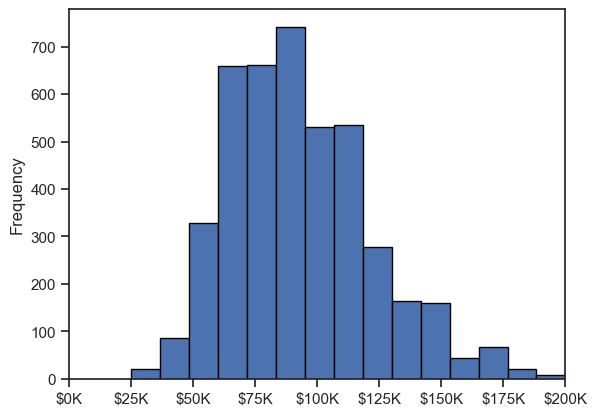

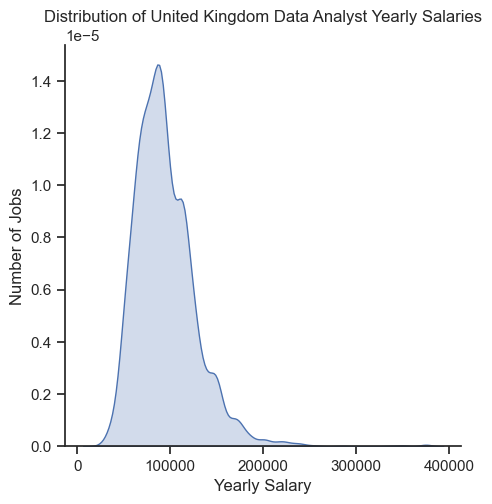

In [45]:
import seaborn as sns
sns.set_theme(style='ticks')
df_DA_US['salary_year_avg'].plot(kind = 'hist',bins=30,edgecolor ='black')
plt.xlim(0,200000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
sns.displot(df_DA_US['salary_year_avg'],kind = 'kde',fill = True)
plt.title("Distribution of United Kingdom Data Analyst Yearly Salaries")
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

In [10]:
job_titles = ['Data Analyst','Data Engineer','Data Scientist']
df_US=df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

#plt.boxplot('job_list',labels ='job_titles',vert=False)
#df_DA_US['salary_year_avg'].plot(kind='box',vert=False)
#plt.title('Salary Distributions of Data Analyst in the US')
#plt.xlabel("Median Salary ($USD)")
#ax = plt.gca()
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))

In [11]:
df_US = df_US.dropna(subset=['salary_year_avg'])

In [12]:
job_list = [df_US[df_US['job_title_short']==job_title]['salary_year_avg']for job_title in job_titles]

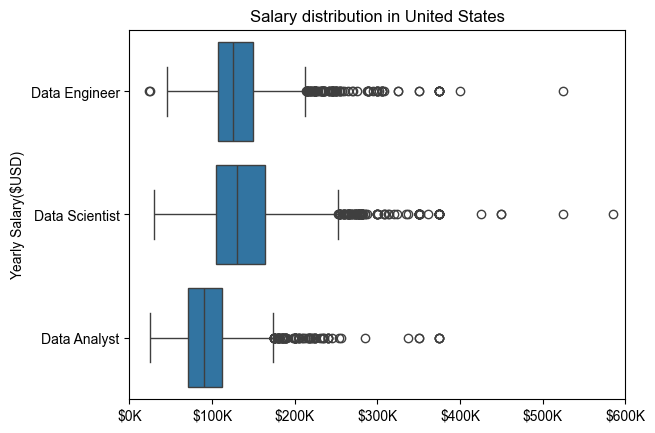

In [15]:
import seaborn as sns 
sns.boxplot(data=df_US,x='salary_year_avg',y='job_title_short')
sns.set_theme(style='ticks')
#plt.boxplot(job_list,labels =job_titles,vert=False)
plt.title("Salary distribution in United States")
plt.xlabel("")
ax =plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.ylabel("Yearly Salary($USD)")
plt.show()